In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Not required - using Pandas instead
'''
with open('iris.data') as f:
    lines = f.read().splitlines()
xs = [line.split(',')[:4] for line in lines if len(line) > 1]
y = [line.split(',')[-1] for line in lines if len(line) > 1]

#print(lines)
#print(xs)
#print(y)
'''

"\nwith open('iris.data') as f:\n    lines = f.read().splitlines()\nxs = [line.split(',')[:4] for line in lines if len(line) > 1]\ny = [line.split(',')[-1] for line in lines if len(line) > 1]\n\n#print(lines)\n#print(xs)\n#print(y)\n"

In [3]:
df_iris = pd.read_csv('iris.data', names = ['PL', 'SL', 'PW', 'SW', 'Classification'])
df_iris['Classification'] = df_iris['Classification'].str.replace('Iris-', '')
df_iris.head()

,PL,SL,PW,SW,Classification
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Exercise 1:
Plot petal length vs petal width, for all flowers in the dataset. Use a different marker depending on the variety, i.e. use a different marker for versicolor than virginica, etc. so that three clouds of points emerge. Do the same for other combinations: PL vs SW, etc. In total you should produce six different plots.

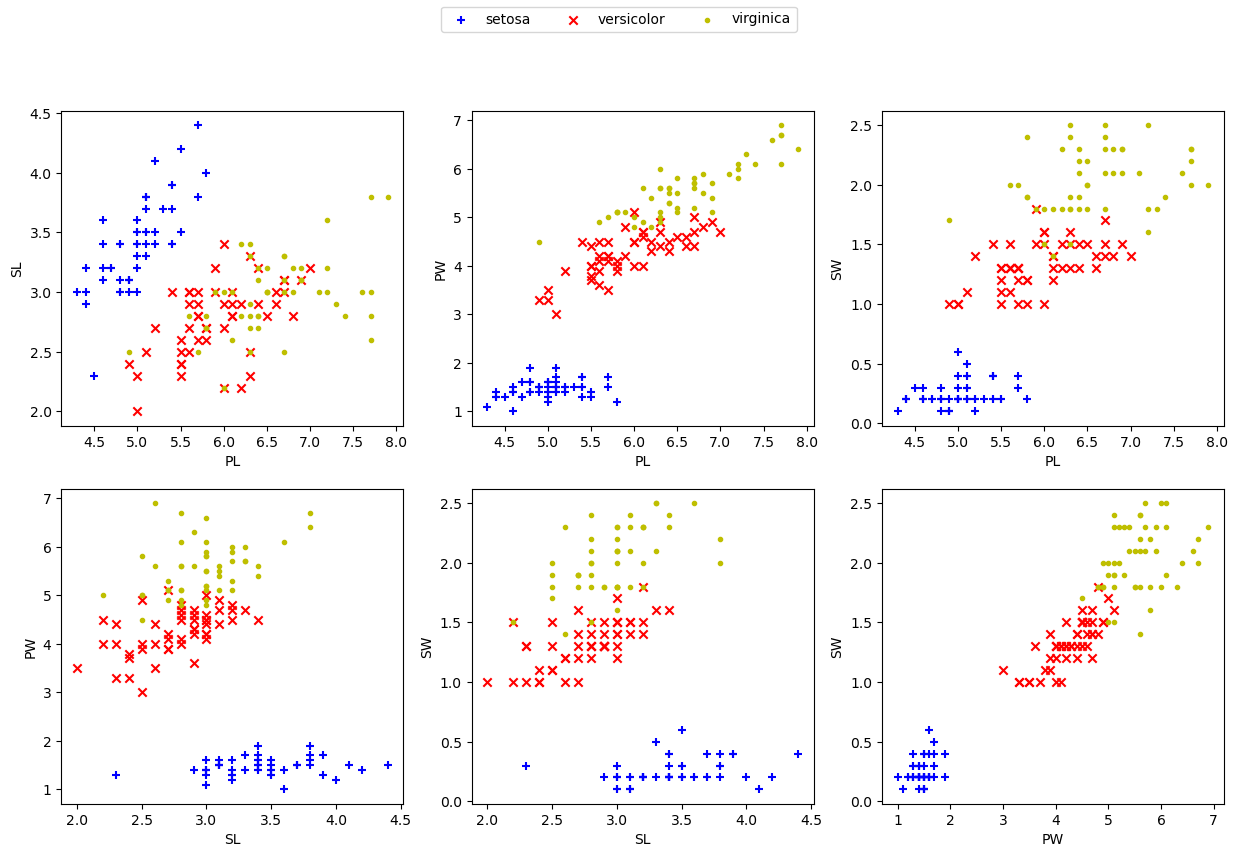

In [4]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15,9))
#axs[0,0].scatter(df_iris['PL'], df_iris['SL'])
classes = df_iris['Classification'].unique()
markers = ['+', 'x', '.']
cols = ['b', 'r', 'y']
plots = [[['PL', 'SL'], ['PL', 'PW'], ['PL', 'SW']], [['SL', 'PW'], ['SL', 'SW'], ['PW', 'SW']]]

for r in range(axs.shape[0]):
    for c in range(axs.shape[1]):
        ax = axs[r,c]
        ax.set_xlabel(plots[r][c][0])
        ax.set_ylabel(plots[r][c][1])
        for i in range(len(classes)):
            df = df_iris[df_iris['Classification'] == classes[i]]
            ax.scatter(df[plots[r][c][0]], df[plots[r][c][1]], marker=markers[i], color=cols[i], label=classes[i])

handles, labels = ax.get_legend_handles_labels()
plt.figlegend(handles, labels, loc = 'upper center', ncol=3)
plt.show()

# Exercise 2:
Examine the file iris.data in your favourite editor. Explain why the dataset has a rasterised appearance in the plots.

In [5]:
df_iris

,PL,SL,PW,SW,Classification
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


The dataset appears rasterized as there is a precision of 0.1 units for all dimensions (PL, SL, PW, SW).
Combined with the fact that the datapoints appear to be clustered close together (based on the plots shown in Exercise 1),  implies that the data points are unlikely to span a large range. The close clustering of the datapoints, the limited variance of the data points, and the fact that a single unit of precision (0.1 units) forms a large proportion of the x and y axes results in the rasterized appearance of the plots.

# Exercise 3:
In one of the plots, draw a straight line between the points labelled as setosa and the other points. Use this to estimate a decision boundary for the variables in this plot, i.e. produce the equation of a line that approximates your boundary. Then convert this boundary into a perceptron with two weights and a bias.

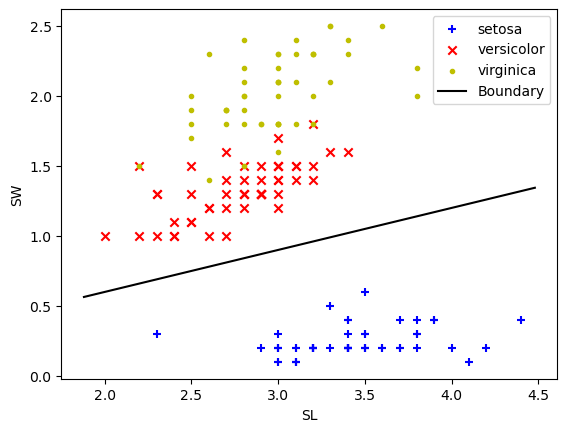

In [6]:
x1 = 'SL'
x2 = 'SW'

def plot_chart(x1, x2, classes, markers, cols):
    for i in range(len(classes)):
        df = df_iris[df_iris['Classification'] == classes[i]]
        plt.scatter(df[x1], df[x2], marker=markers[i], color = cols[i], label = classes[i])
        plt.xlabel(x1)
        plt.ylabel(x2)

plot_chart(x1,x2,classes,markers,cols)
w0 = 0
w1 = 0.3

x_min, x_max = plt.xlim()

xs = np.arange(x_min, x_max, 0.1)
ys = np.array([w0 + w1*xs])[0]

plt.plot(xs,ys,color='k', label='Boundary')
plt.legend()
plt.show()

# Exercise 4:
The perceptron you found in Exercise 3 operates on two input variables. In the iris dataset each point is four dimensional. Describe a simple extension from the perceptron you found in Exercise 3 so that it operates on all four input variables.

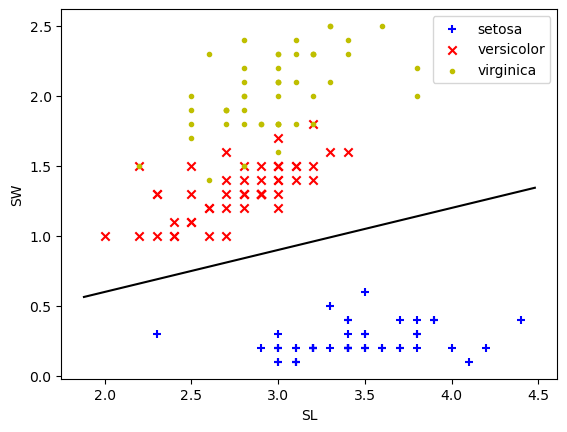

In [26]:
x1 = 'SL'
x2 = 'SW'

w0 = 0
w_sw = 1
w_sl = 0.3
w_pl = 0
w_pw = 0

plot_chart(x1,x2, classes,markers,cols)

ys = np.array([w0 + w_sl*xs])[0]
plt.plot(xs,ys,color='k')
plt.xlabel(x1)
plt.ylabel(x2)
plt.legend()
plt.show()

In [8]:
'''
df = df_iris.iloc[:, :4]
headings = ['Bias'] + list(df.columns)
print(f'Order of weights: {headings}')
df['Bias'] = 1
df = df[headings]

X = df.to_numpy().T
W = np.array([w0, w_pl, w_sl, w_pw, w_sw])
Y = W.dot(X).T
print(Y)
'''

"\ndf = df_iris.iloc[:, :4]\nheadings = ['Bias'] + list(df.columns)\nprint(f'Order of weights: {headings}')\ndf['Bias'] = 1\ndf = df[headings]\n\nX = df.to_numpy().T\nW = np.array([w0, w_pl, w_sl, w_pw, w_sw])\nY = W.dot(X).T\nprint(Y)\n"

# Exercise 5
Perform the same exercise for a perceptron that has to decide virginica vs non-virginica. Write a small programme to evaluate how accurate your perceptron is. For example, count the number of misclassifications. If you want to go formal, present a confusion matrix although this is slightly overkill for a simple problem like this.

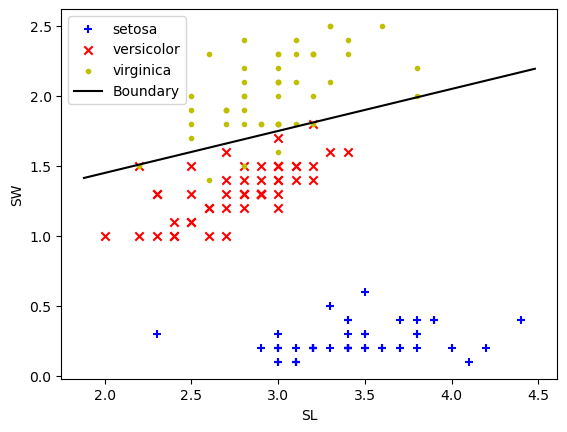

In [66]:
plot_chart(x1,x2,classes,markers,cols)
w0 = 0.85
w_sw = 1
w_sl = 0.3
w_pl = 0
w_pw = 0

ys = np.array([w0 + w_sl*xs])[0]

plt.plot(xs, ys, color='k', label='Boundary')
plt.legend()
plt.show()

In [10]:
# Calculating the Prediction and coding the actuals
def create_perceptron(df, classification, w0, w1, x1, x2):
    df['Y_predict'] = df.apply(lambda x: 
                                          (1 if x[x2] >= w0+w1*x[x1] else 0)
                                          , axis=1)
    df['Y_actual'] = df.apply(lambda x: (1 if x['Classification']==classification else 0), axis = 1)
    return df

df_vir = create_perceptron(df_iris.copy(), 'virginica', w0, w_sl, 'SL', 'SW')
df_5_wrong = df_vir[df_vir['Y_actual'] != df_vir['Y_predict']]
df_5_wrong

,PL,SL,PW,SW,Classification,Y_predict,Y_actual
119,6.0,2.2,5.0,1.5,virginica,0,1
125,7.2,3.2,6.0,1.8,virginica,0,1
129,7.2,3.0,5.8,1.6,virginica,0,1
133,6.3,2.8,5.1,1.5,virginica,0,1
134,6.1,2.6,5.6,1.4,virginica,0,1


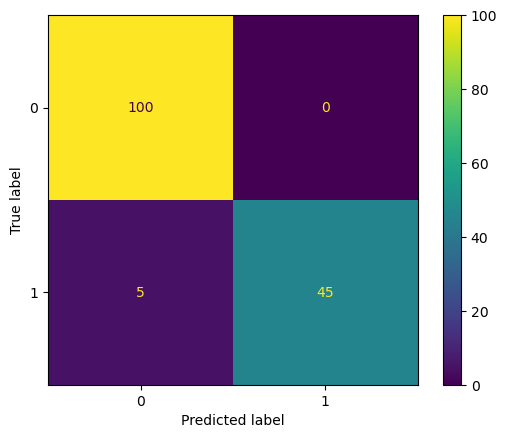

In [11]:
import sklearn.metrics as metrics
# Creating confusion matrix

def create_cm(df):
    cm = metrics.confusion_matrix(df['Y_actual'], df['Y_predict'])
    cm_show = metrics.ConfusionMatrixDisplay(confusion_matrix = cm)
    cm_show.plot()
    plt.show()

create_cm(df_vir)

# Exercise 6
It is not possible to make an accurate perceptron that decides versicolor vs. non-versicolor. Explain why. Nonetheless, try to build a perceptron that attempts to make this decision. It will not be very accurate. Try to give an estimate for how well it does.

It is almost impossible to do with a Perceptron, as there is no set of dimensions that make versicolor linearly separable.
The classification sits 'between' two other classifications ('virginica' and 'setosa') - minisming the false positives for one of these classifications would maximise the false positives for the other, while minimising the false positives for both would result in a minimisation of the true positives.

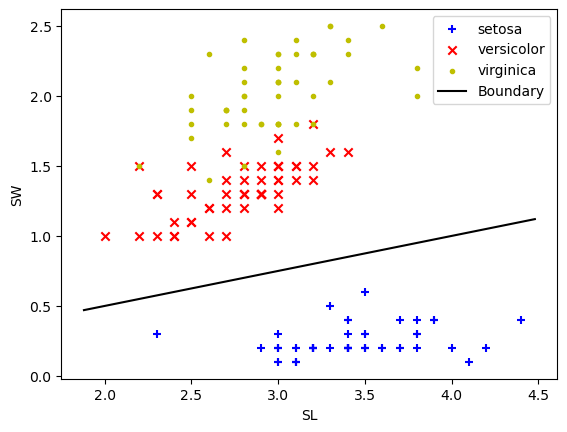

In [12]:
plot_chart(x1,x2,classes,markers,cols)
w0 = 0
w_sw = 1
w_sl = 0.25
w_pl = 0
w_pw = 0

x_min,x_max = plt.xlim()
xs = np.arange(x_min, x_max, 0.05)
ys = np.array([w0 + w_sl*xs])[0]

plt.plot(xs, ys, color='k', label='Boundary')
plt.legend()
plt.show()

      PL   SL   PW   SW Classification  Y_predict  Y_actual
50   7.0  3.2  4.7  1.4     versicolor          1         1
51   6.4  3.2  4.5  1.5     versicolor          1         1
52   6.9  3.1  4.9  1.5     versicolor          1         1
53   5.5  2.3  4.0  1.3     versicolor          1         1
54   6.5  2.8  4.6  1.5     versicolor          1         1
..   ...  ...  ...  ...            ...        ...       ...
145  6.7  3.0  5.2  2.3      virginica          1         0
146  6.3  2.5  5.0  1.9      virginica          1         0
147  6.5  3.0  5.2  2.0      virginica          1         0
148  6.2  3.4  5.4  2.3      virginica          1         0
149  5.9  3.0  5.1  1.8      virginica          1         0

[95 rows x 7 columns]


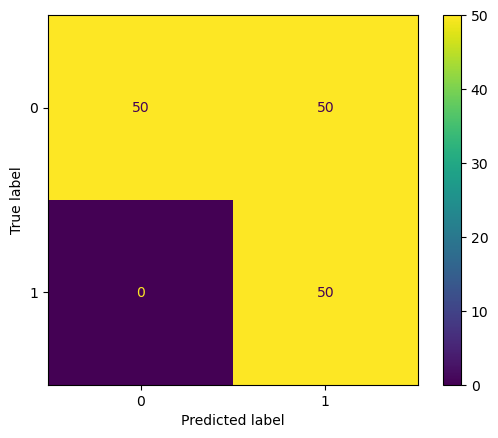

In [13]:
df_ver = create_perceptron(df_iris.copy(), 'versicolor', w0, w_sl, 'SL', 'SW')
df_5_wrong = df_ver[df_ver['Y_actual'] != df_vir['Y_predict']]
print(df_5_wrong)
create_cm(df_ver)

# Exercise 7
Use the three perceptrons you have developed in the previous question. The target patterns are one-over-three coding ('one-hot coding') indicating which variety of iris a given data point corresponds to. From the previous exercise we know that we will not have a very successful classifier.

Now add an extra layer, which uses the output of the previous layer as an input, implementing the logic that if a pattern is neither setosa nor virginica it is likely to be versicolor. This can be single perceptron with weights appropriately set. Construct this network by hand. Implement it in a small program. Evaluate its accuracy. This can be done with an inverted OR gate, which has simple perceptron implementation.

In [89]:
# Weights - of form: [w0, w_sw, w_sl, w_pw, w_pl]
df = df_iris.iloc[:, :4]
headings = ['Bias', 'SW', 'SL', 'PW', 'PL']
print(f'Order of weights: {headings}')
df['Bias'] = 1
df = df[headings]

# Getting target values
df_d = pd.get_dummies(df_iris['Classification'])

w0_setosa = np.array([0, -1, 0.3, 0, 0])
w0_versicolor = np.array([0, -1, 0.25, 0, 0])
w0_virginica = np.array([-0.85, 1, -0.3, 0, 0])
w0 = np.array([w0_setosa, w0_versicolor, w0_virginica])

X = df.to_numpy().T
y0 = w0.dot(X)
y0 = np.where(y0 >=0, 1, 0)

for i in range(len(y0[1])):
    if not(y0[0][i]==1 or y0[2][i]==1):
        y0[1][i]= 1
    else: y0[1][i]= 0

print(y0.shape)
print(df_d.T.shape)

Order of weights: ['Bias', 'SW', 'SL', 'PW', 'PL']
(3, 150)
(3, 150)


In [113]:
pred_vs_act = y0.dot(df_d.to_numpy())
print(pred_vs_act)
TP_rate = pred_vs_act.trace()/df_iris.shape[0]
print(TP_rate)
FP = np.sum(pred_vs_act) - pred_vs_act.trace()
FP_rate = FP/df_iris.shape[0]
print(FP_rate)

[[50  0  0]
 [ 0 50  5]
 [ 0  0 45]]
0.9666666666666667
0.03333333333333333


# Exercise 8
Explain why it is not necessary to split the data into a training and a test set for the previous exercise.

It is not necessary to split the data into training and test sets for the previous exercise because through process of elimination, we know that if an Iris is not Setosa and also not Virginica, then the only option remaining is to be a Versicolor.
This would not be the case if we suspected that more types of Irises were possible.

*Actual Answer: Because we have constructed the data by hand rather than trained it with the dataset*